In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('../datasets/wine_data.csv', header=None, usecols=[0,1,2], names=['ClassLabel', 'Alcohol', 'Malic Acid'])
df.head()

,ClassLabel,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ClassLabel  178 non-null    int64  
 1   Alcohol     178 non-null    float64
 2   Malic Acid  178 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.3 KB


In [10]:
df.describe()

,ClassLabel,Alcohol,Malic Acid
count,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348
std,0.775035,0.811827,1.117146
min,1.000000,11.030000,0.740000
25%,1.000000,12.362500,1.602500
50%,2.000000,13.050000,1.865000
75%,3.000000,13.677500,3.082500
max,3.000000,14.830000,5.800000


<Axes: xlabel='Malic Acid', ylabel='Density'>

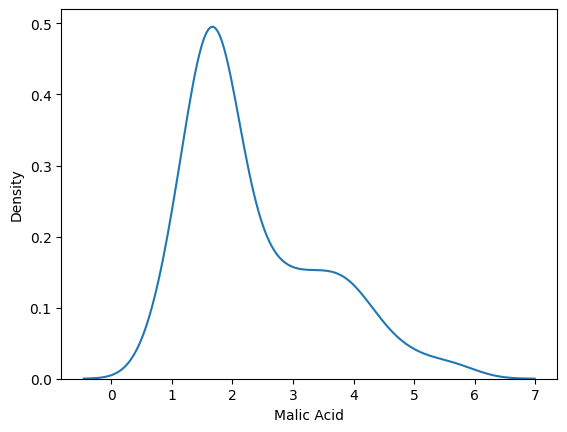

In [8]:
# pdf of malic acid
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Density'>

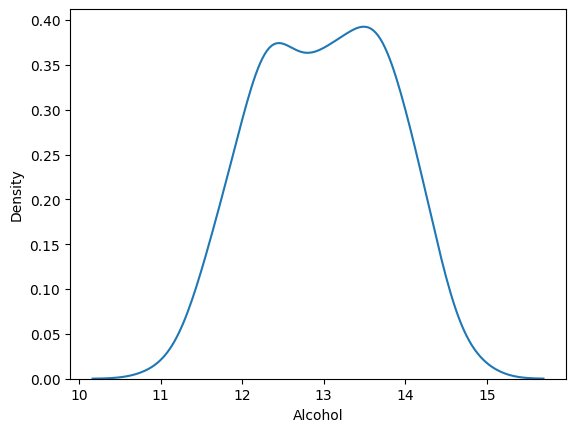

In [11]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

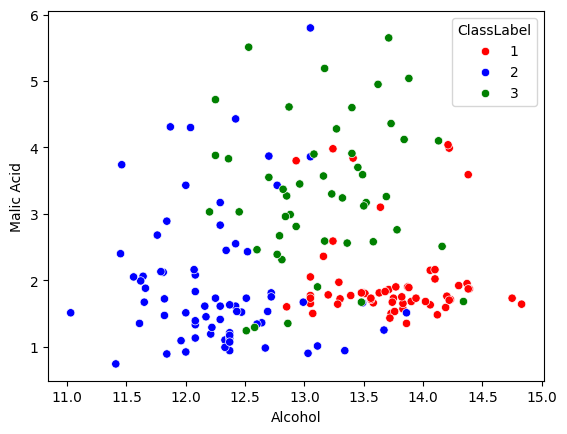

In [16]:
# scatter plot betwen Alcohol and Malic Acid
color_dict = {1:'Red', 3:'Green', 2:'Blue'}
sns.scatterplot(x='Alcohol', y='Malic Acid', data=df, hue='ClassLabel', palette=color_dict)

## Train Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('ClassLabel', axis=1), df['ClassLabel'], test_size=0.2, random_state=0)

X_train.shape, X_test.shape

((142, 2), (36, 2))

In [17]:
df.head()

,ClassLabel,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [19]:
# axis = 0 operates along rows
# axis = 1 operates along cols
# by default axes = 0
df.drop('ClassLabel', axis=1)

,Alcohol,Malic Acid
0,14.23,1.71
1,13.20,1.78
2,13.16,2.36
3,14.37,1.95
4,13.24,2.59
...,...,...
173,13.71,5.65
174,13.40,3.91
175,13.27,4.28
176,13.17,2.59


## Normalization

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to train set. It will learn the parameters (min and max values are the parameter in MinMaxScaling)
scaler.fit(X_train)

# Transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[0.71505376, 0.51323829],
       [0.44623656, 0.16089613],
       [0.15860215, 0.25458248],
       [0.63709677, 0.64562118],
       [0.66397849, 0.21792261]])

In [26]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=['Alcohol', 'Malic Acid'])
X_test_scaled = pd.DataFrame(X_test_scaled, columns=['Alcohol', 'Malic Acid'])

In [28]:
np.round(X_train.describe(), 1)

,Alcohol,Malic Acid
count,142.0,142.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.7
25%,12.3,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [29]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic Acid
count,142.0,142.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


Text(0.5, 1.0, 'Alcohol Distribution After Scaling')

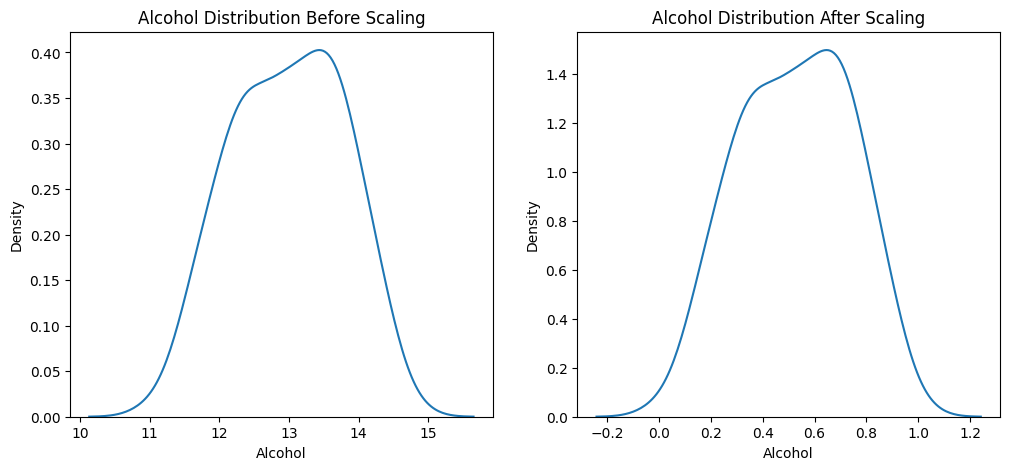

In [53]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
sns.kdeplot(X_train['Alcohol'], ax=axes[0])
axes[0].set_title('Alcohol Distribution Before Scaling')

sns.kdeplot(X_train_scaled['Alcohol'], ax=axes[1])
axes[1].set_title('Alcohol Distribution After Scaling')

# before scaling and after scaling the value distribution has not changed

Text(0.5, 1.0, 'Malic Acid distribution After Scaling')

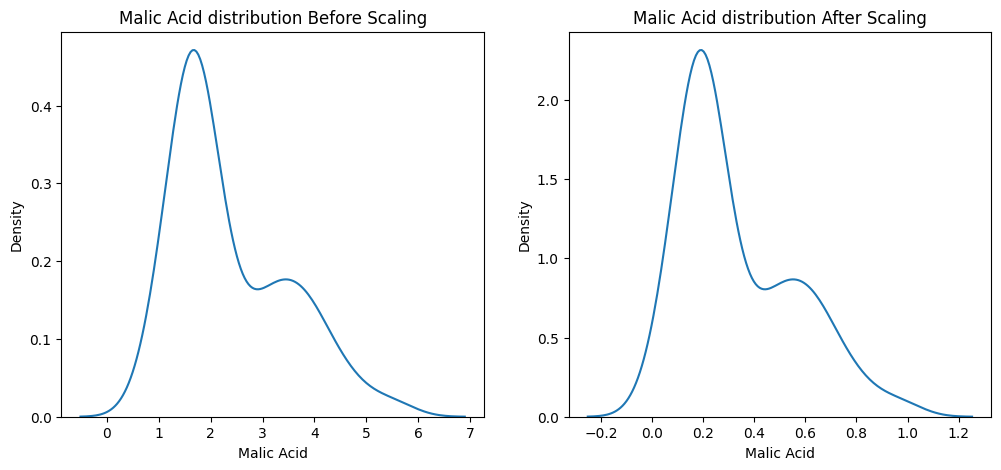

In [54]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
sns.kdeplot(X_train['Malic Acid'], ax=axes[0])
axes[0].set_title('Malic Acid distribution Before Scaling')

sns.kdeplot(X_train_scaled['Malic Acid'], ax=axes[1])
axes[1].set_title('Malic Acid distribution After Scaling')

# before scaling and after scaling the value distribution has not changed

## NOTE: Distribution shape might change in some cases
# The impact of outlier gets reduced compared to the original data -- since we are trying to squeeze in everything in a unit rectangle.

Text(0.5, 1.0, 'After Scaling')

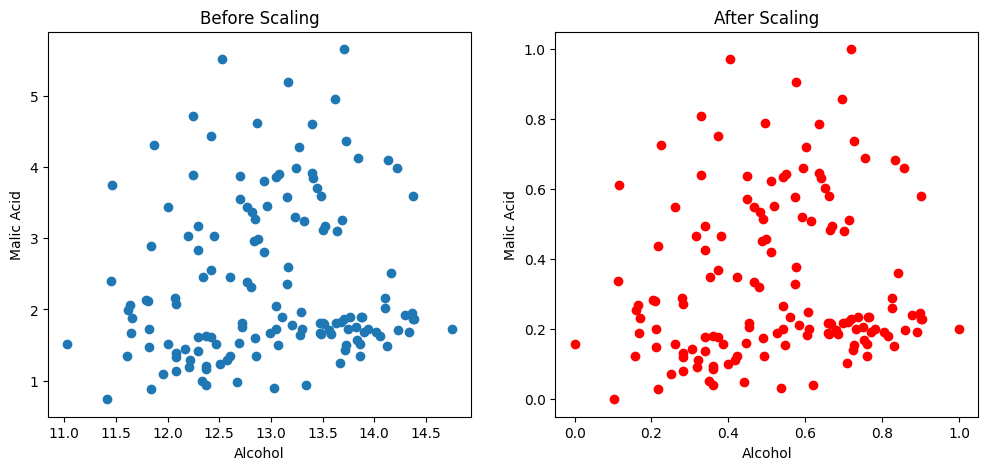

In [37]:
# scatter plot before and after scaling
fig, axes = plt.subplots(1,2,figsize=(12,5))

axes[0].scatter(X_train['Alcohol'], X_train['Malic Acid'])
axes[0].set_xlabel('Alcohol')
axes[0].set_ylabel('Malic Acid')
axes[0].set_title('Before Scaling')

axes[1].scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic Acid'], color='red')
axes[1].set_xlabel('Alcohol')
axes[1].set_ylabel('Malic Acid')
axes[1].set_title('After Scaling')

# Distribution is same, only difference is after scaling values are squeezed within [0,1] range
# Original shape of the data is retained

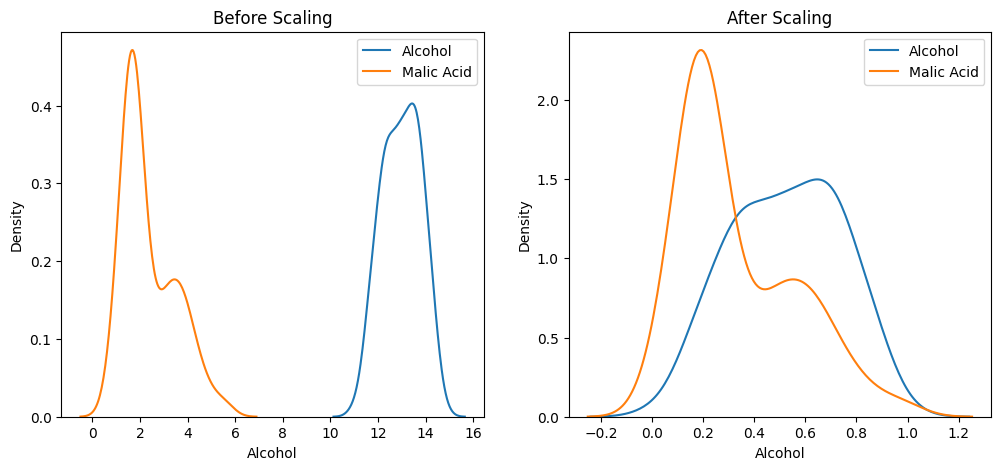

In [52]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.kdeplot(X_train['Alcohol'], ax=axes[0], label='Alcohol')
sns.kdeplot(X_train['Malic Acid'], ax=axes[0], label='Malic Acid')

axes[0].set_title('Before Scaling')
axes[0].legend()


sns.kdeplot(X_train_scaled['Alcohol'], ax=axes[1], label='Alcohol')
sns.kdeplot(X_train_scaled['Malic Acid'], ax=axes[1], label='Malic Acid')

axes[1].set_title('After Scaling')
axes[1].legend()

# after scaling both features are operating on the same scale.
# -ve values and > 1 values are there because of kde plot works on inferenece (statistics concept)